# Lichess Matchmaking EDA

This notebook explores the public Lichess games dataset as a proxy for 1v1 competitive matchmaking. The goal is to understand rating balance, outcome predictability, time-control behavior, and practical signals for a matchmaking policy.

## Dataset

- Kaggle: https://www.kaggle.com/datasets/datasnaek/chess
- Zenodo mirror: https://zenodo.org/records/5978831
- Direct CSV: https://zenodo.org/records/5978831/files/games.csv?download=1

Run `python scripts/download_data.py` from the repository root before executing this notebook.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.append(str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matchmaking_system.data import load_games, prepare_match_records
from matchmaking_system.features import add_matchmaking_features

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
raw = load_games(ROOT / 'data/raw/games.csv')
raw.shape, raw.head()

((20058, 16),
          id  rated    created_at  last_move_at  turns victory_status winner  \
 0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
 1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
 2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
 3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
 4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   
 
   increment_code       white_id  white_rating      black_id  black_rating  \
 0           15+2       bourgris          1500          a-00          1191   
 1           5+10           a-00          1322     skinnerua          1261   
 2           5+10         ischia          1496          a-00          1500   
 3           20+0  daniamurashov          1439  adivanov2009          1454   
 4           30+3      nik221107          1523  adivanov2009          1469   
 
                                  

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 8.6 MB


In [4]:
raw.isna().mean().sort_values(ascending=False).head(10)

id                0.0
rated             0.0
created_at        0.0
last_move_at      0.0
turns             0.0
victory_status    0.0
winner            0.0
increment_code    0.0
white_id          0.0
white_rating      0.0
dtype: float64

## Match Balance

A fair 1v1 match should have a small skill gap and an expected win probability close to 50%.

In [5]:
matches = prepare_match_records(raw, include_draws=True)
matches = add_matchmaking_features(matches)
matches[['white_rating', 'black_rating', 'rating_gap', 'abs_rating_gap', 'elo_white_win_prob', 'elo_uncertainty']].describe()

,white_rating,black_rating,rating_gap,abs_rating_gap,elo_white_win_prob,elo_uncertainty
count,20058.000000,20058.000000,20058.000000,20058.000000,20058.000000,20058.000000
mean,1596.631868,1588.831987,7.799880,173.091435,0.507541,0.619730
std,291.253376,291.036126,249.036667,179.214854,0.238046,0.286843
min,784.000000,789.000000,-1605.000000,0.000000,0.000097,0.000194
25%,1398.000000,1391.000000,-108.000000,45.000000,0.349395,0.399676
50%,1567.000000,1562.000000,3.000000,115.000000,0.504317,0.680584
75%,1793.000000,1784.000000,122.000000,241.000000,0.668695,0.871199
max,2700.000000,2723.000000,1499.000000,1605.000000,0.999821,1.000000


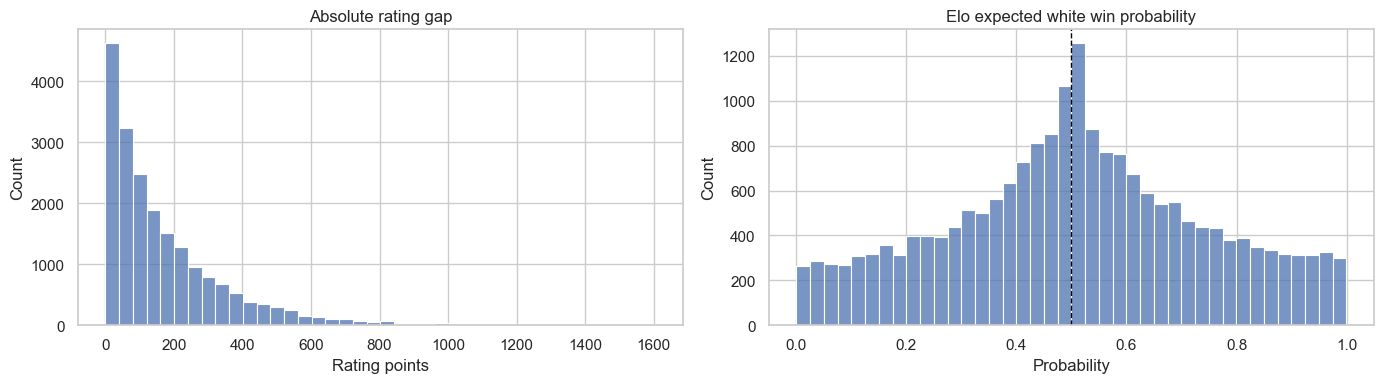

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(matches['abs_rating_gap'], bins=40, ax=axes[0])
axes[0].set_title('Absolute rating gap')
axes[0].set_xlabel('Rating points')

sns.histplot(matches['elo_white_win_prob'], bins=40, ax=axes[1])
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Elo expected white win probability')
axes[1].set_xlabel('Probability')
plt.tight_layout()

## Outcome Patterns

We compare actual outcomes with rating-derived expectations. This is the bridge from EDA to an ML-assisted matchmaking policy.

In [7]:
matches['winner'].value_counts(normalize=True).rename('share').to_frame()

,share
winner,
white,0.498604
black,0.454033
draw,0.047363


In [8]:
binary = prepare_match_records(raw, include_draws=False)
binary = add_matchmaking_features(binary)
binary['rating_gap_bin'] = pd.cut(binary['rating_gap'], bins=[-1000, -400, -200, -100, 0, 100, 200, 400, 1000])
calibration = binary.groupby('rating_gap_bin', observed=True).agg(
    games=('white_win', 'size'),
    actual_white_win_rate=('white_win', 'mean'),
    elo_expected_white_win_rate=('elo_white_win_prob', 'mean'),
    avg_abs_rating_gap=('abs_rating_gap', 'mean'),
).reset_index()
calibration

,rating_gap_bin,games,actual_white_win_rate,elo_expected_white_win_rate,avg_abs_rating_gap
0,"(-1000, -400]",943,0.159067,0.047095,560.586426
1,"(-400, -200]",1978,0.245197,0.170087,281.354904
2,"(-200, -100]",2089,0.362374,0.305317,143.725706
3,"(-100, 0]",4356,0.476584,0.440979,41.504362
4,"(0, 100]",4292,0.563607,0.563482,44.668686
5,"(100, 200]",2274,0.670624,0.696973,145.642040
6,"(200, 400]",2061,0.786997,0.830753,282.232411
7,"(400, 1000]",1054,0.879507,0.952375,558.907021


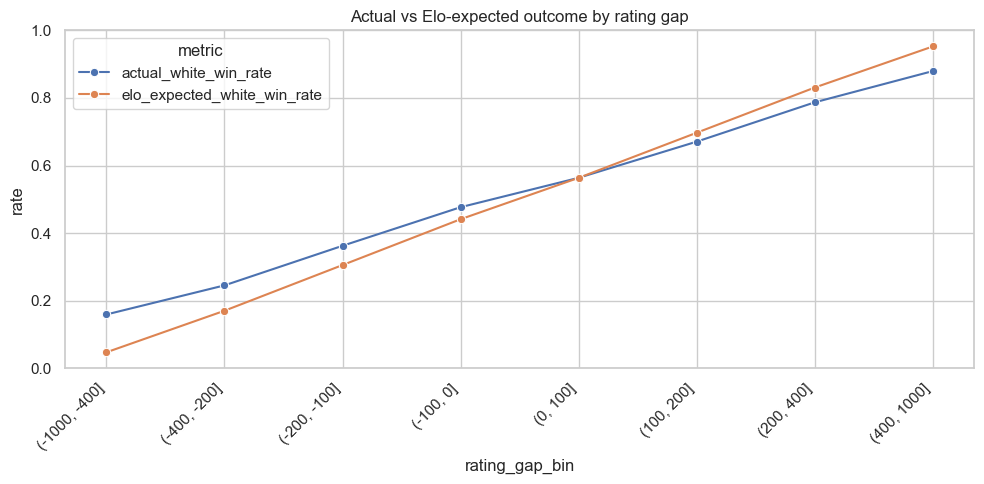

In [9]:
plt.figure(figsize=(10, 5))
plot_df = calibration.melt(
    id_vars='rating_gap_bin',
    value_vars=['actual_white_win_rate', 'elo_expected_white_win_rate'],
    var_name='metric',
    value_name='rate',
)
sns.lineplot(data=plot_df, x=plot_df['rating_gap_bin'].astype(str), y='rate', hue='metric', marker='o')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('Actual vs Elo-expected outcome by rating gap')
plt.tight_layout()

## Time Control and Engagement Proxies

The dataset does not include satisfaction or retention directly. We use game length, decisive outcomes, and timeout/resignation status as portfolio-friendly proxies for match experience.

In [10]:
time_control_summary = matches.groupby('increment_code').agg(
    games=('id', 'size'),
    avg_turns=('turns', 'mean'),
    median_abs_rating_gap=('abs_rating_gap', 'median'),
    avg_uncertainty=('elo_uncertainty', 'mean'),
).sort_values('games', ascending=False).head(15)
time_control_summary

,games,avg_turns,median_abs_rating_gap,avg_uncertainty
increment_code,,,,
10+0,7721,62.849242,103.0,0.639611
15+0,1311,60.532418,110.0,0.621528
15+15,850,56.960000,86.0,0.702102
5+5,738,61.256098,122.5,0.605418
5+8,697,54.076040,150.0,0.564894
8+0,588,67.930272,97.5,0.671205
10+5,579,56.462867,118.0,0.622763
15+10,461,63.429501,86.0,0.678767
20+0,448,57.453125,116.5,0.605946


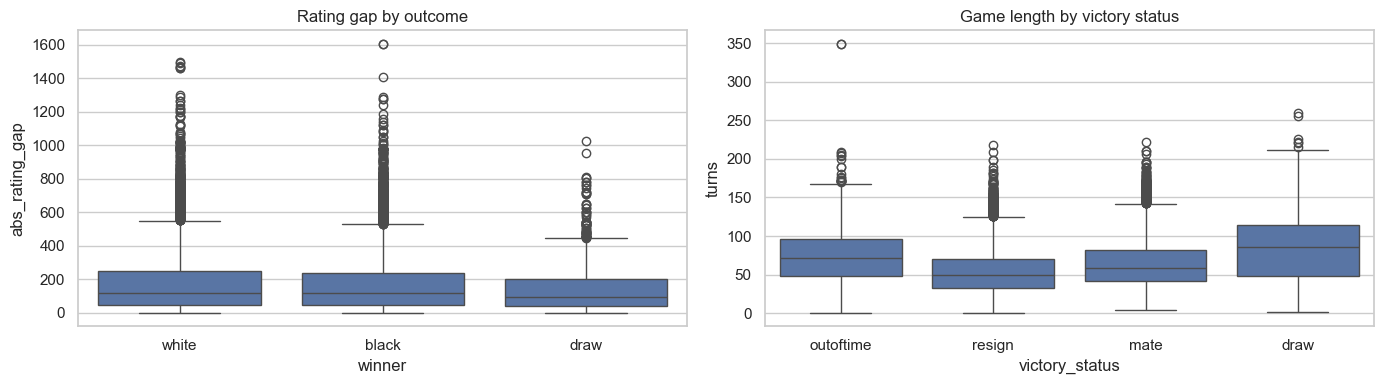

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=matches, x='winner', y='abs_rating_gap', ax=axes[0])
axes[0].set_title('Rating gap by outcome')

top_statuses = matches['victory_status'].value_counts().index
sns.boxplot(data=matches[matches['victory_status'].isin(top_statuses)], x='victory_status', y='turns', ax=axes[1])
axes[1].set_title('Game length by victory status')
plt.tight_layout()

## EDA Findings to Carry Forward

- Rating gap is the core fairness signal and should be a hard or heavily weighted constraint.
- Elo expected probability creates an interpretable baseline for win-probability calibration.
- Time-control and game-length features are useful context for engagement-aware matching.
- Draws should be kept for fairness analysis but filtered or modeled separately for binary win prediction.
- A portfolio-ready solution should compare policies offline before proposing online A/B testing.